# Comparison of SVM and Deep Learning Models
Performance metrics on the test set and spatio-temporal performance analysis

In [1]:
import warnings
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.svm import SVR, LinearSVR, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error,
)
import geopandas as gpd
import contextily as ctx
import shapely

import joblib

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

MODEL_DIR = Path("../models")
VISUALS_DIR = Path("../plots")
TARGET = "Total_Trip_Start" # Target variable for prediction

In [2]:
# Load all models from the models directory
model_files = list(MODEL_DIR.glob("*.joblib"))

# Load the test set
df_test = pd.read_parquet("../data/prediction_split/res_8/df_test.parquet")


In [3]:
# Feature columns for the different models
BASIC_FEATURES = [
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "is_weekend", "is_holiday", "day_of_week",
    "lat", "lon", "scikit_distance_to_loop", "base_demand"
]
POI_COLS = [c for c in df_test.columns if c.startswith("poi_cat_")]
WEATHER = ["2m_temp_c", "total_precip_mm", "snow_cov", "snow_depth", "wind_speed"]

feature_sets = {
    "basic": BASIC_FEATURES,
    "basic+poi": BASIC_FEATURES + POI_COLS,
    "basic+weather": BASIC_FEATURES + WEATHER,
    "basic+poi+weather": BASIC_FEATURES + POI_COLS + WEATHER,
}
# TODO: use this feature_sets dictionary to load the correct features for each model based on its name or metadata.
# For that lets use the names in our model names and match them to the keys in this dictionary. 
# For example, if a model name contains "basic+poi", we will use the corresponding feature set from this dictionary.

In [ ]:
# Create a List to store model performance metrics
performance_metrics = []
prediction_df = pd.DataFrame()
y_test = df_test[TARGET].values
prediction_df["y_test"] = y_test

# Inspect the loaded models
for model_file in model_files:
    model = joblib.load(model_file)
    # Find feature set based on feature elements
    if set(model['features']) == set(feature_sets["basic"]):
        feature_set = "basic"
    elif set(model['features']) == set(feature_sets["basic+poi"]):
        feature_set = "basic+poi"
    elif set(model['features']) == set(feature_sets["basic+weather"]):
        feature_set = "basic+weather"
    elif set(model['features']) == set(feature_sets["basic+poi+weather"]):
        feature_set = "basic+poi+weather"
    else:
        feature_set = "unknown"
    
    print(f"Loaded model: {model_file.name}")
    print(f"Model Hyperparameters: {model['model']}")
    print(f"Target Value: {model['target']}")
    print(f"Features Count: {len(model['features'])}")
    print(f"Feature Set: {feature_set}")

    # Model Evaluation on test set
    X_test = df_test[model['features']].values
    y_pred = model['model'].predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    prediction_df["y_test" + f"_{model_file.stem}"] = y_pred
    
    print(f"MAE: {mae:.4f}, R2: {r2:.4f}, RMSE: {rmse:.4f}")
    print("-" * 40)
    # Store the metrics in the DataFrame
    performance_metrics.append({
        "model_file": model_file.name,
        "model_type": type(model['model']).__name__,
        "feature_set": feature_set,
        "mae": mae,
        "r2": r2,
        "rmse": rmse,
    })

Loaded model: svr_best_8.joblib
Model Hyperparameters: SVR(C=10, cache_size=500)
Target Value: Total_Trip_Start
Features Count: 30
Feature Set: basic+poi+weather
Metrics: {'Model': 'Tuned SVR (rbf)', 'MAE': 0.3621372993602783, 'RMSE': 2.6653662445591193, 'R2': 0.8439693872709221}
----------------------------------------
Loaded model: svr_best.joblib
Model Hyperparameters: SVR(C=50, cache_size=500)
Target Value: Total_Trip_Start
Features Count: 25
Feature Set: basic+poi
Metrics: {'Model': 'Tuned SVR (rbf)', 'MAE': 0.34491972823373696, 'RMSE': 2.4996575058542883, 'R2': 0.8627674788880126}
----------------------------------------
Loaded model: svr_best_7.joblib
Model Hyperparameters: SVR(C=50, cache_size=500, kernel='poly')
Target Value: Total_Trip_Start
Features Count: 25
Feature Set: basic+poi
Metrics: {'Model': 'Tuned SVR (poly)', 'MAE': 2.4348391367357123, 'RMSE': 16.039788101835654, 'R2': 0.37125012032018734}
----------------------------------------
Loaded model: svr_best_8_no_poi_no

## Performance Metrics Table
Here we compare our performance metrics on the test set for multiple SVM and NN models

In [14]:
# Convert the performance metrics list to a DataFrame
performance_df = pd.DataFrame(performance_metrics)
performance_df = performance_df.sort_values(by="model_file").reset_index(drop=True)
performance_df

,model_file,model_type,feature_set,mae,r2,rmse
0,svr_best.joblib,SVR,basic+poi,0.344920,0.862767,2.499658
1,svr_best_7.joblib,SVR,basic+poi,2.434839,0.371250,16.039788
2,svr_best_8.joblib,SVR,basic+poi+weather,0.362137,0.843969,2.665366
3,svr_best_8_no_poi_no_weather.joblib,SVR,basic,0.343935,0.853410,2.583474


In [ ]:
# Find best performing model based on R2 score by model_type
best_models = performance_df.loc[performance_df.groupby("model_type")["r2"].idxmax()]

# Prediction Comparison

In [ ]:
prediction_df.columns

## Performance Visualization

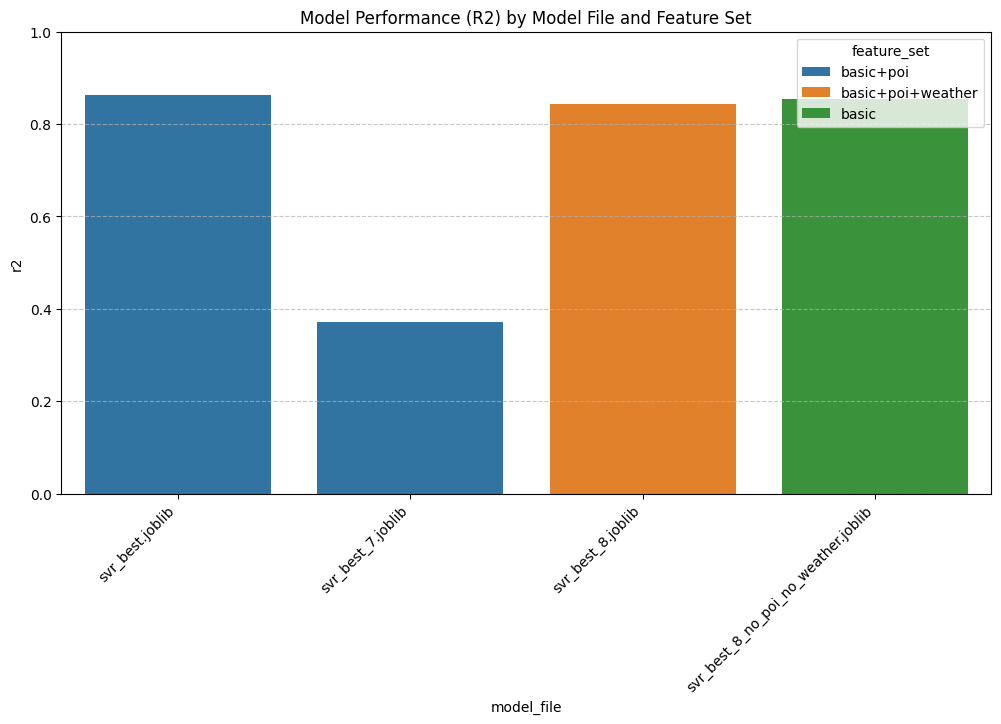

In [12]:
# Visualize the R2 for all models in a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=performance_df, x="model_file", y="r2", hue="feature_set")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.title("Model Performance (R2) by Model File and Feature Set")   
plt.grid(axis="y", linestyle="--", alpha=0.7)

## Spatio Performance Analytics

In [ ]:
# Community area outlines, used as a spatial reference overlay in the choropleths.
community_areas = gpd.read_file(Path("..") / "data" / "chicago_community_areas.gpkg")

def get_hexagon_grid(data, h3_col="h3_index"):
    """
    Build a GeoDataFrame of H3 hexagon polygons, preserving all columns from the source.
    """
    def _to_polygon(cell):
        boundary = h3.cell_to_boundary(cell)
        return shapely.geometry.Polygon([(lng, lat) for lat, lng in boundary])

    if isinstance(data, pd.Series):
        h3_list = list(data)
        df = pd.DataFrame({"h3_index": h3_list})
    else:
        h3_list = list(data[h3_col])
        df = data.reset_index(drop=True)
    geometries = [_to_polygon(c) for c in h3_list]
    return gpd.GeoDataFrame(df, geometry=geometries, crs="EPSG:4326")


def create_choropleth_plot(gdf, value_col="poi_count", title="", boundaries=None,
                           cmap="YlOrRd", figsize=(6, 8), k=7):
    """
    Create a static matplotlib choropleth of hexagon values with Chicago basemap.
    """
    if boundaries is None:
        boundaries = community_areas
    fig, ax = plt.subplots(figsize=figsize)
    gdf.to_crs(epsg=3857).plot(
        ax=ax, column=value_col, cmap=cmap, scheme="quantiles", k=k,
        edgecolor="none", alpha=0.8, legend=True, zorder=1,
        legend_kwds=dict(title=value_col.replace("_", " ").title(),
                         loc="lower right", fontsize=8, title_fontsize=9),
        missing_kwds=dict(color="lightgrey", label="No data"),
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    boundaries.to_crs(epsg=3857).boundary.plot(
        ax=ax, color="#222", linewidth=1.0, alpha=0.9, zorder=3)
    ax.set_axis_off()
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    plt.tight_layout()
    return fig, ax

In [ ]:
# Per-hexagon performance for the best model
df_eval = df_test[["h3_index", TARGET]].copy()
df_eval["y_pred"] = y_pred_best
df_eval["abs_err"] = (df_eval[TARGET] - df_eval["y_pred"]).abs()
df_eval["sq_err"] = (df_eval[TARGET] - df_eval["y_pred"]) ** 2

grp = df_eval.groupby("h3_index")
hex_perf = grp.agg(
    n_obs=(TARGET, "size"),
    mean_actual=(TARGET, "mean"),
    var_actual=(TARGET, "var"),
    mae=("abs_err", "mean"),
    mse=("sq_err", "mean"),
)
hex_perf["rmse"] = np.sqrt(hex_perf["mse"])
ss_res = grp["sq_err"].sum()
ss_tot = hex_perf["var_actual"].fillna(0) * (hex_perf["n_obs"] - 1)
hex_perf["r2"] = 1 - ss_res / ss_tot.replace(0, np.nan)
hex_perf["rel_error"] = hex_perf["mae"] / hex_perf["mean_actual"].replace(0, np.nan)
hex_perf = hex_perf.drop(columns=["var_actual", "mse"]).reset_index()
hex_perf_gdf = get_hexagon_grid(hex_perf, h3_col="h3_index")

busy = hex_perf[hex_perf["mean_actual"] > 1]
n_bad = (busy["r2"] < -0.3).sum()

### SVR - Support Vector Regression

In [ ]:
# fig-svm-hex-mae - MAE per hexagon for the best SVR model
fig, ax = create_choropleth_plot(
    hex_perf_gdf,
    value_col='mae',
    title='SVR absolute error per hexagon (MAE, trips/hour)\nred = larger prediction error',
    cmap='YlOrRd',
    k=7,
)
plt.show()

In [ ]:
# fig-svm-hex-mre - MRE per hexagon for the best SVR model
fig, ax = create_choropleth_plot(
    hex_perf_gdf,
    value_col='rel_error',
    title='SVR relative error per hexagon (MRE, trips/hour)\nred = larger prediction error',
    cmap='YlOrRd',
    k=7,
)
plt.show()

In [ ]:
# fig-svm-hex-r2 - R² per hexagon for the best SVR model
fig, ax = create_choropleth_plot(
    hex_perf_gdf,
    value_col='r2',
    title='SVR prediction quality per hexagon (R²)\ngreen = well predicted, grey = too little demand to assess',
    cmap='RdYlGn',
    k=7,
)
plt.show()

### Deep Learning - Neural Network

# Time Performance Analysis

In [ ]:
# On which days of the week does the models perform best/worst?


In [ ]:
# How does the model perform throughout the day?